In [1]:
from __future__ import annotations

import argparse
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.resource_counting import QECGatesCost, get_cost_value

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from exciton.benchmark_tensors import *

In [2]:
shape = (3, 3, )
R_loc = 5
R_c = 30

F = generate_f_tensor(shape, r_cut=R_loc, metric="euclidean")
V = generate_v_tensor(shape, r_loc=R_loc, r_c=R_c, metric="euclidean")

In [3]:
n = V.shape[0]
V_direct = V.reshape(n * n, n * n)  # (p, q) -> (r, s)
V_exchange = np.transpose(V, (0, 2, 1, 3)).reshape(n * n, n * n)  # (p, r) -> (q, s)

print("V tensor shape:", V.shape)
print("V_direct shape:", V_direct.shape)
print("V_exchange shape:", V_exchange.shape)


V tensor shape: (9, 9, 9, 9)
V_direct shape: (81, 81)
V_exchange shape: (81, 81)


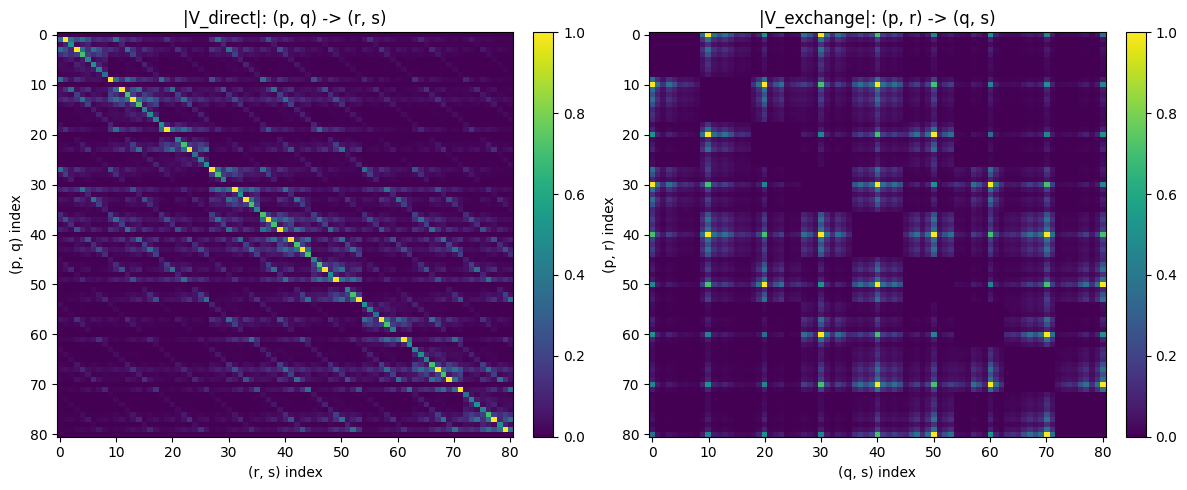

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.abs(V_direct), cmap="viridis", aspect="auto")
axes[0].set_title("|V_direct|: (p, q) -> (r, s)")
axes[0].set_xlabel("(r, s) index")
axes[0].set_ylabel("(p, q) index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.abs(V_exchange), cmap="viridis", aspect="auto")
axes[1].set_title("|V_exchange|: (p, r) -> (q, s)")
axes[1].set_xlabel("(q, s) index")
axes[1].set_ylabel("(p, r) index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [5]:



qrom = QROM.build_from_data(cols, 15)
gc = get_cost_value(qrom, QECGatesCost())


NameError: name 'cols' is not defined

In [6]:
# Short Qualtran example: chain two 4-register oracles with BloqBuilder.

from attrs import frozen
from qualtran import Bloq, BloqBuilder, QUInt, Register, Signature

@frozen
class OracleA(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("j", QUInt(self.bitsize)),
            Register("k", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, j, k, t):
        mod = 1 << self.bitsize
        return i, j, k, (int(t) + int(i) + 2 * int(j) + 3 * int(k)) % mod

@frozen
class OracleB(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("j", QUInt(self.bitsize)),
            Register("k", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, j, k, t):
        mod = 1 << self.bitsize
        return i, j, k, (int(t) + int(i) * int(j) + int(k)) % mod

A = OracleA(bitsize=4)
B = OracleB(bitsize=4)

# Classical check of chained action: B(A(i,j,k,t)).
x0 = (2, 1, 3, 0)
x1 = A.call_classically(*x0)
x2 = B.call_classically(*x1)
print('input      :', x0)
print('after A    :', x1)
print('after B(A) :', x2)

# Circuit-level chaining in Qualtran via BloqBuilder.
bb = BloqBuilder()
i = bb.add_register('i', 4)
j = bb.add_register('j', 4)
k = bb.add_register('k', 4)
t = bb.add_register('t', 4)

out_a = bb.add_d(A, i=i, j=j, k=k, t=t)
out_b = bb.add_d(B, **out_a)
chained_cbloq = bb.finalize(**out_b)
print('chained signature:', chained_cbloq.signature)


input      : (2, 1, 3, 0)
after A    : (2, 1, 3, 13)
after B(A) : (2, 1, 3, 2)
chained signature: Signature((Register(name='i', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='j', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='k', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='t', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>)))


In [ ]:
# End-to-end pipeline: chain several Bloqs -> gate counts -> surface-code costs.

from qualtran import BloqBuilder
from qualtran.resource_counting import GateCounts, QECGatesCost, get_cost_value
from qualtran.surface_code import CCZ2TFactory, MultiFactory, SimpleDataBlock
from qualtran.surface_code.gidney_fowler_model import get_ccz2t_costs

bitsize = 4
query_repetitions = 50_000  # scale this to model the full algorithm workload

A = OracleA(bitsize=bitsize)
B = OracleB(bitsize=bitsize)

# 1) Build one query as a chain of several Bloqs.
bb = BloqBuilder()
state = {
    'i': bb.add_register('i', bitsize),
    'j': bb.add_register('j', bitsize),
    'k': bb.add_register('k', bitsize),
    't': bb.add_register('t', bitsize),
}

for bloq in [A, B, A, B]:
    state = bb.add_d(bloq, **state)

query_cbloq = bb.finalize(**state)

# 2) Compile/count at QEC gate model level.
qec = get_cost_value(query_cbloq, QECGatesCost())
qec_dict = qec.asdict() if hasattr(qec, 'asdict') else vars(qec)

toffoli_per_query = int(
    qec_dict.get('toffoli', 0) + qec_dict.get('and_bloq', 0) + qec_dict.get('cswap', 0)
)
# If explicit T is unavailable in this Qualtran version, use a conservative proxy from Toffoli.
t_per_query = int(qec_dict.get('t', 4 * toffoli_per_query))

total_toffoli = toffoli_per_query * query_repetitions
total_t = t_per_query * query_repetitions

# 3) Surface-code compilation (runtime + physical footprint).
# Logical qubits: lower bound from explicit algorithm registers in this toy example.
n_algo_qubits = 4 * bitsize

factory = MultiFactory(
    base_factory=CCZ2TFactory(distillation_l1_d=19, distillation_l2_d=31),
    n_factories=4,
)
data_block = SimpleDataBlock(data_d=31, routing_overhead=0.5)

pcost = get_ccz2t_costs(
    n_logical_gates=GateCounts(toffoli=total_toffoli),
    n_algo_qubits=n_algo_qubits,
    phys_err=1e-3,
    cycle_time_us=1.0,
    factory=factory,
    data_block=data_block,
)

print('--- Per-query costs ---')
print('QEC counts:', qec_dict)
print('toffoli_per_query:', toffoli_per_query)
print('t_per_query (or proxy):', t_per_query)

print('\n--- Scaled algorithm costs ---')
print('query_repetitions:', query_repetitions)
print('total_toffoli:', total_toffoli)
print('total_t:', total_t)
print('logical_qubits (algo lower bound):', n_algo_qubits)
print('wall_time_hours:', pcost.duration_hr)
print('wall_time_days:', pcost.duration_hr / 24.0)
print('physical_qubits:', pcost.footprint)
print('physical_qubits_million:', pcost.footprint / 1e6)
print('failure_probability:', pcost.failure_prob)


In [7]:
# How to combine multiple Bloqs into one CompositeBloq.

def combine_bloqs_to_single_bloq(bloq_sequence, bitsize=4):
    """Return one CompositeBloq equivalent to applying bloq_sequence in order."""
    bb = BloqBuilder()
    state = {
        'i': bb.add_register('i', bitsize),
        'j': bb.add_register('j', bitsize),
        'k': bb.add_register('k', bitsize),
        't': bb.add_register('t', bitsize),
    }

    for bloq in bloq_sequence:
        state = bb.add_d(bloq, **state)

    return bb.finalize(**state)

combined = combine_bloqs_to_single_bloq([OracleA(4), OracleB(4), OracleA(4)], bitsize=4)
print('combined bloq type:', type(combined).__name__)
print('combined signature:', combined.signature)

combined_qec = get_cost_value(combined, QECGatesCost())
print('combined QEC counts:', combined_qec.asdict() if hasattr(combined_qec, 'asdict') else vars(combined_qec))


combined bloq type: CompositeBloq
combined signature: Signature((Register(name='i', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='j', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='k', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='t', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>)))


DecomposeNotImplementedError: OracleA does not declare a decomposition.

In [9]:
# Demo: apply a Bloq to only a subset of registers.

@frozen
class OracleSubsetIT(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, t):
        mod = 1 << self.bitsize
        return i, (int(t) + 5 * int(i) + 1) % mod

subset_bloq = OracleSubsetIT(bitsize=4)

bb = BloqBuilder()
state = {
    'i': bb.add_register('i', 4),
    'j': bb.add_register('j', 4),
    'k': bb.add_register('k', 4),
    't': bb.add_register('t', 4),
    'flag': bb.add_register('flag', 1),
}

# Apply only on i,t. j,k,flag are carried through unchanged.
subset_out = bb.add_d(subset_bloq, i=state['i'], t=state['t'])
state.update(subset_out)  # updates i,t only

# You can continue with a full-register bloq afterward.
full_out = bb.add_d(OracleA(4), i=state['i'], j=state['j'], k=state['k'], t=state['t'])
state.update(full_out)  # preserves flag

subset_pipeline = bb.finalize(**state)
print('subset pipeline signature:', subset_pipeline.signature)

# Optional: gate counting needs decomposable/component costable Bloqs.
try:
    subset_qec = get_cost_value(subset_pipeline, QECGatesCost())
    print('subset pipeline counts:', subset_qec.asdict() if hasattr(subset_qec, 'asdict') else vars(subset_qec))
except Exception as exc:
    print('QEC count unavailable for this toy oracle set:', type(exc).__name__, exc)


subset pipeline signature: Signature((Register(name='i', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='j', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='k', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='t', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='flag', dtype=QBit(), _shape=(), side=<Side.THRU: 3>)))
QEC count unavailable for this toy oracle set: DecomposeNotImplementedError OracleSubsetIT does not declare a decomposition.


In [10]:
# Tensor entry oracle as a Qualtran Bloq (decomposable via QROM + rotations).
import numpy as np

from attrs import field, frozen
from qualtran import BQUInt, Bloq, BloqBuilder, DecomposeTypeError, QBit, Register, Signature
from qualtran.bloqs.basic_gates import Ry
from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.symbolics import is_symbolic


@frozen
class TensorEntryOracleBloq(Bloq):
    r"""Entry oracle for tensor M[i,j,m,l] with multi-index registers.

    Implements a decomposition in the same style as Qualtran's ExplicitEntryOracle:
      1) QROM-load discretized angles theta(i,j,m,l)
      2) Apply controlled Ry ladder on flag qubit q
      3) Unload QROM workspace

    Notes:
    - This decomposition matches the standard nonnegative-amplitude model used by
      ExplicitEntryOracle, i.e. it encodes a0 = M[i,j,m,l] with M in [0, 1].
    - If you need signed/complex M, add a phase/sign sub-oracle on top of this.

    Tensor shape convention:
      M.shape == (L,)*D + (L,)*D + (2*R_c+1,)*D + (2*R_loc+1,)*D
    """

    D: int
    L: int
    R_c: int
    R_loc: int
    M: np.ndarray = field(
        converter=lambda x: np.asarray(x) if not isinstance(x, np.ndarray) else x,
        eq=lambda d: tuple(np.asarray(d).flat),
    )
    entry_bitsize: int = 10

    def __attrs_post_init__(self):
        expected = (self.L,) * self.D + (self.L,) * self.D + (2 * self.R_c + 1,) * self.D + (2 * self.R_loc + 1,) * self.D
        if self.M.shape != expected:
            raise ValueError(f"M has shape {self.M.shape}, expected {expected}.")
        if not is_symbolic(self.entry_bitsize) and int(self.entry_bitsize) < 1:
            raise ValueError("entry_bitsize must be >= 1")

        # Mimic ExplicitEntryOracle constraints for amplitude-loading decomposition.
        mmin = float(np.min(self.M))
        mmax = float(np.max(self.M))
        if mmin < 0.0 or mmax > 1.0:
            raise ValueError(
                "For this decomposition, all M entries must be in [0, 1]. "
                f"Observed min={mmin}, max={mmax}."
            )

    @property
    def i_bitsize(self) -> int:
        return int(np.ceil(np.log2(self.L)))

    @property
    def j_bitsize(self) -> int:
        return int(np.ceil(np.log2(self.L)))

    @property
    def m_bitsize(self) -> int:
        return int(np.ceil(np.log2(2 * self.R_c + 1)))

    @property
    def l_bitsize(self) -> int:
        return int(np.ceil(np.log2(2 * self.R_loc + 1)))

    @property
    def signature(self) -> Signature:
        return Signature(
            [
                Register("q", QBit()),
                Register("m", BQUInt(self.m_bitsize, 2 * self.R_c + 1), shape=(self.D,)),
                Register("l", BQUInt(self.l_bitsize, 2 * self.R_loc + 1), shape=(self.D,)),
                Register("i", BQUInt(self.i_bitsize, self.L), shape=(self.D,)),
                Register("j", BQUInt(self.j_bitsize, self.L), shape=(self.D,)),
            ]
        )

    @property
    def _qrom_theta(self):
        # theta_table = arccos(M)/pi * 2^entry_bitsize (same encoding as ExplicitEntryOracle)
        if is_symbolic(self.entry_bitsize):
            raise DecomposeTypeError(f"Cannot decompose symbolic {self=}")
        theta_table = np.arccos(np.asarray(self.M, dtype=np.float64)) / np.pi * (2 ** int(self.entry_bitsize))
        return QROM.build_from_data(theta_table, target_bitsizes=(int(self.entry_bitsize),))

    def entry_value(self, i, j, m, l) -> float:
        i_t = tuple(int(x) for x in i)
        j_t = tuple(int(x) for x in j)
        m_t = tuple(int(x) for x in m)
        l_t = tuple(int(x) for x in l)
        return float(self.M[i_t + j_t + m_t + l_t])

    def build_composite_bloq(self, bb: BloqBuilder, q, m, l, i, j):
        if is_symbolic(self.entry_bitsize):
            raise DecomposeTypeError(f"Cannot decompose symbolic {self=}")

        i_regs = list(i)
        j_regs = list(j)
        m_regs = list(m)
        l_regs = list(l)

        target = bb.allocate(int(self.entry_bitsize))

        # Axis order in M: i(0..D-1), j(0..D-1), m(0..D-1), l(0..D-1)
        sel_in = {}
        for d in range(self.D):
            sel_in[f"selection{d}"] = i_regs[d]
        for d in range(self.D):
            sel_in[f"selection{self.D + d}"] = j_regs[d]
        for d in range(self.D):
            sel_in[f"selection{2 * self.D + d}"] = m_regs[d]
        for d in range(self.D):
            sel_in[f"selection{3 * self.D + d}"] = l_regs[d]

        out = bb.add_d(self._qrom_theta, **sel_in, target0_=target)

        for d in range(self.D):
            i_regs[d] = out[f"selection{d}"]
        for d in range(self.D):
            j_regs[d] = out[f"selection{self.D + d}"]
        for d in range(self.D):
            m_regs[d] = out[f"selection{2 * self.D + d}"]
        for d in range(self.D):
            l_regs[d] = out[f"selection{3 * self.D + d}"]
        target = out["target0_"]

        target_bits = bb.split(target)
        for k, tbit in enumerate(target_bits):
            tbit, q = bb.add(Ry(2 * np.pi * (2 ** -(k + 1))).controlled(), ctrl=tbit, q=q)
            target_bits[k] = tbit
        target = bb.join(target_bits)

        out = bb.add_d(self._qrom_theta.adjoint(), **{
            **{f"selection{d}": i_regs[d] for d in range(self.D)},
            **{f"selection{self.D + d}": j_regs[d] for d in range(self.D)},
            **{f"selection{2 * self.D + d}": m_regs[d] for d in range(self.D)},
            **{f"selection{3 * self.D + d}": l_regs[d] for d in range(self.D)},
            "target0_": target,
        })

        for d in range(self.D):
            i_regs[d] = out[f"selection{d}"]
        for d in range(self.D):
            j_regs[d] = out[f"selection{self.D + d}"]
        for d in range(self.D):
            m_regs[d] = out[f"selection{2 * self.D + d}"]
        for d in range(self.D):
            l_regs[d] = out[f"selection{3 * self.D + d}"]
        target = out["target0_"]

        bb.free(target)
        return {
            "q": q,
            "m": np.array(m_regs, dtype=object),
            "l": np.array(l_regs, dtype=object),
            "i": np.array(i_regs, dtype=object),
            "j": np.array(j_regs, dtype=object),
        }


def build_tensor_entry_oracle_bloq(
    M: np.ndarray, D: int, L: int, R_c: int, R_loc: int, entry_bitsize: int = 10
) -> TensorEntryOracleBloq:
    return TensorEntryOracleBloq(
        D=int(D), L=int(L), R_c=int(R_c), R_loc=int(R_loc), M=np.asarray(M), entry_bitsize=int(entry_bitsize)
    )


# Small demo (kept tiny for memory):
D_demo, L_demo, Rc_demo, Rloc_demo = 2, 3, 1, 1
shape_demo = (L_demo,) * D_demo + (L_demo,) * D_demo + (2 * Rc_demo + 1,) * D_demo + (2 * Rloc_demo + 1,) * D_demo
M_demo = 0.1 * np.ones(shape_demo, dtype=np.float64)  # must be in [0,1] for this decomposition
entry_bloq = build_tensor_entry_oracle_bloq(M_demo, D_demo, L_demo, Rc_demo, Rloc_demo, entry_bitsize=8)
print('entry bloq signature:', entry_bloq.signature)
print('sample entry M[i,j,m,l]=', entry_bloq.entry_value(i=(1, 2), j=(0, 1), m=(1, 2), l=(0, 1)))


entry bloq signature: Signature((Register(name='q', dtype=QBit(), _shape=(), side=<Side.THRU: 3>), Register(name='m', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='l', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='i', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='j', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>)))
sample entry M[i,j,m,l]= 0.1
